# NB14 — Investigation des amas t-SNE : proximité d'embedding ou vraie ressemblance de code ? (RQ2)
### Cluster Investigation: Embedding Proximity or Real Code Similarity? (RQ2)

**Contexte.** Retour des professeurs sur la présentation du 7 août : le résultat RQ2 existant
(signal statistique réel mais modeste, établi via lift k-NN dans NB10/NB11) n'avait jamais été
vérifié contre le contenu réel du code. La figure S6.1 de NB11 (t-SNE, TF-IDF, p02659 — le
problème au lift verdict le plus élevé) montre, au lieu d'un blob uniforme, de nombreux petits
îlots compacts, dont plusieurs visiblement dominés par une seule couleur de verdict. Question
posée par les profs : cette proximité dans la projection 2D correspond-elle à une vraie
ressemblance de code, ou est-ce une coïncidence d'embedding (des codes en réalité très
différents que TF-IDF placerait près l'un de l'autre) ?

**Méthode.** On détecte ces îlots automatiquement (DBSCAN, pas à l'œil), puis pour chacun on
compare la similarité de code **interne au cluster** à celle d'un échantillon aléatoire de même
taille et même composition de verdict, tiré hors de tout cluster retenu — même logique que le
lift déjà utilisé partout dans ce projet : ne jamais lire un chiffre brut, toujours le comparer
à une référence.

---

**Context.** Feedback from the professors on the August 7 presentation: the existing RQ2 result
(a real but modest statistical signal, established via k-NN lift in NB10/NB11) had never been
checked against the actual content of the code. NB11's S6.1 figure (t-SNE, TF-IDF, p02659 — the
problem with the highest verdict lift) shows, instead of a uniform blob, many small compact
islands, several visibly dominated by a single verdict color. Question raised by the
professors: does this 2D proximity correspond to real code similarity, or is it an embedding
coincidence (substantially different code that TF-IDF happens to place close together)?

**Method.** These islands are detected automatically (DBSCAN, not by eye), then for each one,
code similarity **inside the cluster** is compared to a random sample of matching size and
verdict composition, drawn from outside every retained cluster — the same logic already used
throughout this project for the lift: never read a raw number, always compare it to a
reference.

In [1]:
import os
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# embedding.py lit data/Project_CodeNet/ via un chemin relatif a la racine du
# projet (meme convention que data_loader.py, voir NB10 cellule 4) -> se
# placer a la racine avant d'importer, sinon read_source_code() echoue
# silencieusement (retourne None) si le kernel demarre dans notebooks/.
if Path.cwd().name == "notebooks":
    os.chdir("..")

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))
import embedding

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "processed" / "embeddings"
PID = "p02659"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EMBEDDINGS_DIR: {EMBEDDINGS_DIR}  (exists={EMBEDDINGS_DIR.exists()})")

PROJECT_ROOT  : /Users/raphael/OJS-submission-analytics
EMBEDDINGS_DIR: /Users/raphael/OJS-submission-analytics/data/processed/embeddings  (exists=True)


## S1 — Localisation automatique des amas (t-SNE + DBSCAN)
### S1 — Automatic Cluster Detection (t-SNE + DBSCAN)

On recharge le corpus TF-IDF multi-problèmes déjà utilisé en NB11, filtré à p02659, et on
reproduit le t-SNE de NB11 S6.1 à l'identique (mêmes paramètres, `random_state=42`) — mêmes
coordonnées 2D que la figure déjà vue.

Pour détecter les amas denses sans a priori visuel, on utilise DBSCAN sur les coordonnées 2D.
Le choix de `eps` est guidé par la distribution des distances au 10ᵉ plus proche voisin
(`min_samples=10`) : `eps=1.5` reste sous la médiane de cette distribution — un choix
délibérément conservateur qui n'isole que les groupes vraiment denses (points quasi
superposés), sans fusionner des régions de verdicts différents comme cela arrive à partir de
`eps=2.5`.

---

We reload the multi-problem TF-IDF corpus already used in NB11, filtered to p02659, and
reproduce NB11 S6.1's t-SNE identically (same parameters, `random_state=42`) — the same 2D
coordinates as the figure already seen.

To detect dense islands without a visual prior, DBSCAN is run on the 2D coordinates. The `eps`
choice is guided by the distribution of distances to the 10th nearest neighbor
(`min_samples=10`): `eps=1.5` stays below that distribution's median — a deliberately
conservative choice that isolates only genuinely dense groups (near-overlapping points),
without merging regions of different verdicts the way `eps=2.5` and above does.

In [2]:
emb  = np.load(EMBEDDINGS_DIR / "embeddings_tfidf_python_multi12.npy")
meta = pl.read_csv(EMBEDDINGS_DIR / "metadata_tfidf_python_multi12.csv")

idx      = np.where((meta["problem_id"] == PID).to_numpy())[0]
sub_emb  = emb[idx]
sub_meta = meta[idx]
print(f"{PID} : {sub_emb.shape[0]} soumissions (tfidf)")

tsne = TSNE(n_components=2, random_state=42, metric='cosine', init='pca')
proj = tsne.fit_transform(sub_emb)

K_NN = 10
nn = NearestNeighbors(n_neighbors=K_NN).fit(proj)
dists, _ = nn.kneighbors(proj)
kdist_median = np.median(dists[:, -1])
print(f"Distance mediane au {K_NN}e plus proche voisin (2D t-SNE) : {kdist_median:.3f}")

EPS = 1.5
MIN_SAMPLES = 10
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(proj)
labels = db.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int((labels == -1).sum())
print(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) : {n_clusters} amas, {n_noise} hors amas / {len(labels)}")

p02659 : 1507 soumissions (tfidf)


Distance mediane au 10e plus proche voisin (2D t-SNE) : 1.755
DBSCAN (eps=1.5, min_samples=10) : 39 amas, 651 hors amas / 1507


In [3]:
statuses = sub_meta["status_code"].to_numpy()

rows = []
for c in sorted(set(labels)):
    if c == -1:
        continue
    mask = labels == c
    sz = int(mask.sum())
    if sz < 15:
        continue
    comp = statuses[mask]
    vals, counts = np.unique(comp, return_counts=True)
    dom = vals[np.argmax(counts)]
    pct = counts.max() / sz * 100
    if pct < 70:
        continue
    rows.append({
        "cluster_id": c, "size": sz, "dominant": dom, "purity_pct": round(float(pct), 1),
        "composition": ", ".join(f"{v}:{ct}" for v, ct in zip(vals, counts)),
        "center_x": round(float(proj[mask, 0].mean()), 1),
        "center_y": round(float(proj[mask, 1].mean()), 1),
    })

summary = pl.DataFrame(rows).sort("size", descending=True)
summary

cluster_id,size,dominant,purity_pct,composition,center_x,center_y
i64,i64,str,f64,str,f64,f64
28,62,"""WA""",79.0,"""RE:13, WA:49""",2.5,27.4
4,51,"""AC""",84.3,"""AC:43, RE:5, WA:3""",37.6,3.9
27,48,"""WA""",87.5,"""RE:6, WA:42""",1.9,-32.1
1,43,"""AC""",88.4,"""AC:38, RE:3, WA:2""",36.7,-12.0
21,40,"""WA""",72.5,"""AC:5, RE:5, TLE:1, WA:29""",-14.9,-5.0
0,28,"""AC""",92.9,"""AC:26, RE:1, WA:1""",-24.2,33.3
34,26,"""RE""",100.0,"""RE:26""",-32.4,-9.0
36,26,"""RE""",100.0,"""RE:26""",-48.7,12.2
33,21,"""RE""",90.5,"""RE:19, WA:2""",-3.5,37.6


In [4]:
out = sub_meta.select(["submission_id", "problem_id", "language", "filename_ext", "status_code"]).with_columns([
    pl.Series("cluster_id", labels),
    pl.Series("tsne_x", proj[:, 0]),
    pl.Series("tsne_y", proj[:, 1]),
])
out.write_csv(EMBEDDINGS_DIR / f"{PID}_clusters_tsne_tfidf.csv")
summary.write_csv(EMBEDDINGS_DIR / f"{PID}_clusters_tsne_tfidf_summary.csv")
print(f"Sauvegarde : {out.height} soumissions, {summary.height} amas retenus")

Sauvegarde : 1507 soumissions, 10 amas retenus


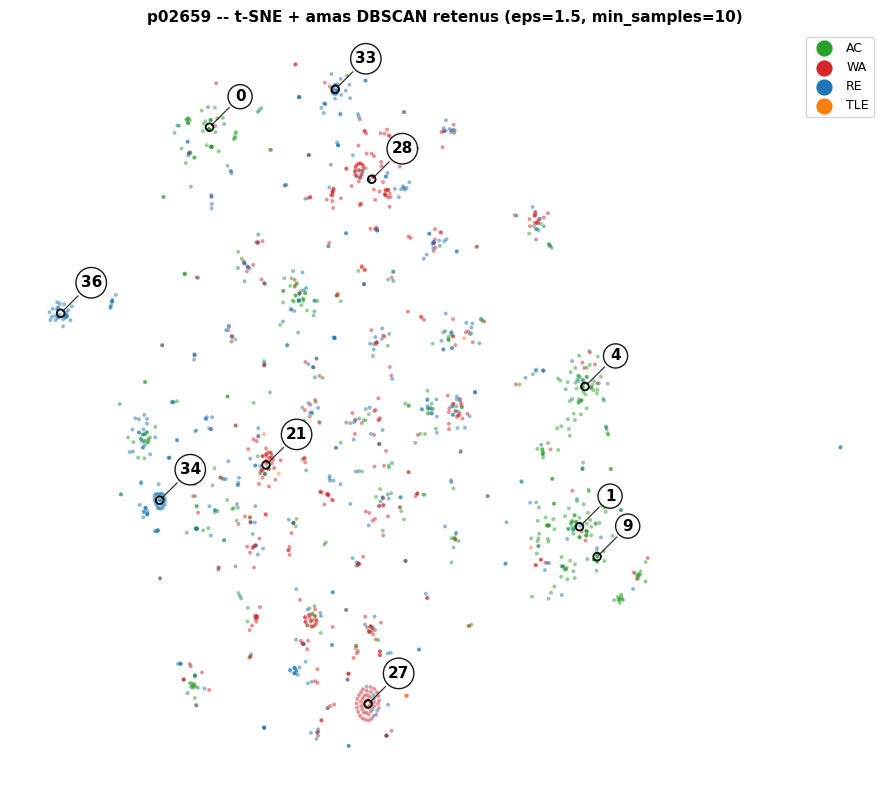

In [5]:
COLOR_MAP = {'AC': '#2ca02c', 'WA': '#d62728', 'RE': '#1f77b4', 'TLE': '#ff7f0e', 'CE': '#9467bd'}

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(proj[:, 0], proj[:, 1], c=[COLOR_MAP.get(s, '#aaaaaa') for s in statuses],
           s=8, alpha=0.5, linewidths=0)
for v, col in COLOR_MAP.items():
    if v in statuses:
        ax.scatter([], [], c=col, s=35, label=v)
for row in summary.iter_rows(named=True):
    cx, cy = row["center_x"], row["center_y"]
    # petit anneau noir = centre exact de l'amas (jamais cache par l'etiquette,
    # decalee a cote via xytext + ligne fine pour rester lisible)
    ax.scatter([cx], [cy], s=30, facecolors='none', edgecolors='black', linewidths=1.3, zorder=5)
    ax.annotate(str(row["cluster_id"]),
                xy=(cx, cy), xycoords='data',
                xytext=(22, 22), textcoords='offset points',
                fontsize=11, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='circle', fc='white', ec='black', alpha=0.9),
                arrowprops=dict(arrowstyle='-', color='black', lw=0.9, alpha=0.8),
                zorder=6)
ax.legend(fontsize=9, markerscale=1.8, framealpha=0.8)
ax.set_title(f'{PID} -- t-SNE + amas DBSCAN retenus (eps={EPS}, min_samples={MIN_SAMPLES})',
             fontsize=11, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

**Résultat.** Le blob « un anneau WA + un cluster RE » vu à l'œil sur S6.1 se décompose en
réalité en plusieurs amas distincts et bien séparés : 4 amas à dominante WA (72–88 % de pureté,
40 à 62 points) et 3 amas à dominante RE, dont **deux purs à 100 %** (26 points chacun) — une
structure plus riche que la lecture visuelle initiale. Le premier cluster RE repéré à l'œil (le
plus à gauche de la figure) correspond exactement à l'amas 36 ci-dessus.

---

**Result.** The "one WA ring + one RE cluster" blob seen by eye on S6.1 actually breaks down
into several distinct, well-separated islands: 4 WA-dominant clusters (72–88% purity, 40 to 62
points) and 3 RE-dominant clusters, including **two 100% pure ones** (26 points each) — a
richer structure than the initial visual read. The first RE cluster spotted by eye (the
leftmost one in the figure) corresponds exactly to cluster 36 above.

**Pour vérification manuelle.** La liste complète des `submission_id` de chaque amas retenu est
imprimée ci-dessous, pour que quiconque lit ce notebook puisse aller consulter directement les
fichiers sous `data/Project_CodeNet/data/p02659/Python/<submission_id>.py` et juger par
soi-même si le code se ressemble vraiment — plutôt que de devoir faire confiance au chiffre
`ratio` de S3. La même information (une ligne par soumission) est aussi dans le CSV sauvegardé
juste au-dessus, `p02659_clusters_tsne_tfidf.csv`, filtrable par `cluster_id`.

---

**For manual verification.** The full list of `submission_id`s for each retained cluster is
printed below, so that anyone reading this notebook can go look directly at the files under
`data/Project_CodeNet/data/p02659/Python/<submission_id>.py` and judge for themselves whether
the code really is similar — rather than having to trust S3's `ratio` number alone. The same
information (one row per submission) is also in the CSV saved just above,
`p02659_clusters_tsne_tfidf.csv`, filterable by `cluster_id`.

In [6]:
for row in summary.sort("cluster_id").iter_rows(named=True):
    cid = row["cluster_id"]
    ids = out.filter(pl.col("cluster_id") == cid)["submission_id"].to_list()
    print(f"cluster {cid:3d}  ({row['dominant']} {row['purity_pct']:.0f}%, n={row['size']})")
    print("  " + ", ".join(ids))
    print()

cluster   0  (AC 93%, n=28)
  s729031435, s652681327, s910568702, s299990040, s195774787, s402292494, s465133053, s391612758, s559000321, s758387460, s804981324, s485153693, s854246770, s103999016, s337098088, s987197012, s084044873, s322221725, s939770837, s168477405, s803227370, s182389701, s023892745, s623454644, s589295042, s053929731, s530233712, s446750734

cluster   1  (AC 88%, n=43)
  s502425159, s827997729, s659487575, s818858642, s991491038, s811260880, s290116774, s718871203, s879078321, s055985712, s132422557, s488031621, s907164533, s374694316, s938915453, s160427629, s830885431, s457017678, s057712081, s353830563, s157627817, s275267853, s241865405, s989306692, s546745133, s479375326, s081245670, s793975296, s909931956, s344619147, s425185833, s112010981, s880465188, s603652153, s951759066, s215313212, s845097800, s692418501, s759434981, s476711746, s623054361, s302213682, s628403930

cluster   4  (AC 84%, n=51)
  s702125913, s903788025, s006320866, s071727651, s953843390

## S2 — Similarité de code par paires
### S2 — Pairwise Code Similarity

Nouvelle fonction `pairwise_code_similarity()` dans `src/embedding.py`. Pour neutraliser les
différences de commentaires/docstrings avant comparaison, elle réutilise
`remove_comments_and_docstrings` — déjà vendorisée dans `src/parser/utils.py` pour le pipeline
GraphCodeBERT-AST (NB13) — puis mesure `difflib.SequenceMatcher(None, code_a, code_b).ratio()`
pour chaque paire (stdlib, aucune dépendance nouvelle). Volontairement **indépendante des
embeddings testés** : comparer les voisinages d'un embedding à une métrique construite à partir
de ce même embedding ne ferait que confirmer qu'il est d'accord avec lui-même.

Vérification ci-dessous sur du code **synthétique fictif** (jamais de vraies soumissions
CodeNet à ce stade) : deux extraits quasi identiques ne différant que par un commentaire
doivent obtenir un score proche de 1,0 une fois le commentaire retiré, un extrait franchement
différent un score nettement plus bas, et un fichier source manquant doit produire une
ligne/colonne `NaN` plutôt qu'un plantage ou une soumission silencieusement ignorée.

---

New `pairwise_code_similarity()` function in `src/embedding.py`. To neutralize
comment/docstring differences before comparing, it reuses `remove_comments_and_docstrings` —
already vendored in `src/parser/utils.py` for the GraphCodeBERT-AST pipeline (NB13) — then
measures `difflib.SequenceMatcher(None, code_a, code_b).ratio()` for every pair (stdlib, no new
dependency). Deliberately **independent of the embeddings under test**: comparing an
embedding's neighborhoods to a metric built from that same embedding would only confirm it
agrees with itself.

Verified below on **fictional, synthetic code** (never real CodeNet submissions at this
stage): two near-identical snippets differing only by a comment should score close to 1.0 once
the comment is stripped, a genuinely different snippet a noticeably lower score, and a missing
source file should produce a `NaN` row/column rather than a crash or a silently dropped
submission.

In [7]:
import tempfile

def _write_fake_submission(root, pid, lang, sid, ext, text):
    d = Path(root) / "data" / pid / lang
    d.mkdir(parents=True, exist_ok=True)
    (d / f"{sid}.{ext}").write_text(text)

with tempfile.TemporaryDirectory() as tmp:
    _write_fake_submission(tmp, "p_fake", "python", "s_a", "py",
                            "# comment A\nn = int(input())\nprint(n * n)\n")
    _write_fake_submission(tmp, "p_fake", "python", "s_b", "py",
                            "# totally different comment\nn = int(input())\nprint(n * n)\n")
    _write_fake_submission(tmp, "p_fake", "python", "s_c", "py",
                            "import sys\n\ndef fib(k):\n    a, b = 0, 1\n    for _ in range(k):\n"
                            "        a, b = b, a + b\n    return a\n\nfor v in sys.stdin.read().split():\n"
                            "    print(fib(int(v)))\n")

    df_test = pl.DataFrame({
        "submission_id": ["s_a", "s_b", "s_c", "s_missing"],
        "problem_id":    ["p_fake"] * 4,
        "language":      ["Python"] * 4,
        "filename_ext":  ["py"] * 4,
    })

    _orig_raw_dir = embedding.RAW_DATA_DIR
    embedding.RAW_DATA_DIR = Path(tmp)
    try:
        sim_test = embedding.pairwise_code_similarity(df_test)
    finally:
        embedding.RAW_DATA_DIR = _orig_raw_dir

assert np.isnan(sim_test[3]).all() and np.isnan(sim_test[:, 3]).all(), "fichier manquant -> NaN attendu"
assert sim_test[0, 1] > 0.9, "A et B ne different que par un commentaire (retire) -> quasi identiques attendu"
assert sim_test[0, 1] > sim_test[0, 2], "A/B doit etre plus similaire que A/C"

print(f"sim(A,B) = {sim_test[0,1]:.3f}  (quasi-identiques apres retrait du commentaire / near-identical after comment strip)")
print(f"sim(A,C) = {sim_test[0,2]:.3f}  (code different / different code)")
print("sim(*, missing) = NaN (fichier absent correctement propage / missing file correctly propagated)")
print("OK")

sim(A,B) = 1.000  (quasi-identiques apres retrait du commentaire / near-identical after comment strip)
sim(A,C) = 0.227  (code different / different code)
sim(*, missing) = NaN (fichier absent correctement propage / missing file correctly propagated)
OK


## S3 — Amas vs référence aléatoire : la proximité 2D reflète-t-elle une vraie ressemblance de code ?
### S3 — Cluster vs Random Baseline: Does 2D Proximity Reflect Real Code Similarity?

Pour chaque amas retenu en S1 : similarité moyenne **interne** (toutes les paires), comparée à
une référence aléatoire de **même taille et même composition de verdict**, tirée parmi les
soumissions p02659 **hors de tout amas retenu** (`seed=42`). La stratification par verdict
isole l'effet propre au cluster de l'effet générique « même verdict, même problème » — plus
stricte que comparer à un échantillon WA quelconque, nécessaire ici puisque la plupart des amas
sont des mélanges (ex. 49 WA + 13 RE) plutôt que purs.

---

For each cluster retained in S1: mean **internal** similarity (all pairs), compared to a
random reference of **matching size and verdict composition**, drawn from p02659 submissions
**outside every retained cluster** (`seed=42`). Stratifying by verdict isolates the
cluster-specific effect from the generic "same verdict, same problem" effect — stricter than
comparing against an arbitrary WA sample, necessary here since most clusters are mixed (e.g. 49
WA + 13 RE) rather than pure.

In [8]:
all_clustered_ids = set(
    out.filter(pl.col("cluster_id").is_in(summary["cluster_id"].to_list()))["submission_id"].to_list()
)

def mean_offdiag(sim: np.ndarray) -> float:
    n = sim.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return float(np.nanmean(sim[mask]))

RNG_SEED = 42
results = []
for row in summary.iter_rows(named=True):
    cid = row["cluster_id"]
    members = out.filter(pl.col("cluster_id") == cid)
    comp = members.group_by("status_code").len().sort("status_code")
    verdict_counts = dict(zip(comp["status_code"].to_list(), comp["len"].to_list()))

    cluster_mean = mean_offdiag(embedding.pairwise_code_similarity(members))

    rng = np.random.default_rng(RNG_SEED)
    baseline_parts = []
    for verdict, k_v in verdict_counts.items():
        pool = sub_meta.filter(
            (pl.col("status_code") == verdict) & (~pl.col("submission_id").is_in(list(all_clustered_ids)))
        )
        sel = rng.choice(pool.height, size=k_v, replace=False)
        baseline_parts.append(pool[sel.tolist()])
    baseline_df = pl.concat(baseline_parts)
    baseline_mean = mean_offdiag(embedding.pairwise_code_similarity(baseline_df))

    results.append({
        "cluster_id": cid, "size": row["size"], "dominant": row["dominant"], "purity_pct": row["purity_pct"],
        "sim_cluster": round(cluster_mean, 4), "sim_baseline": round(baseline_mean, 4),
        "ratio": round(cluster_mean / baseline_mean, 2) if baseline_mean > 0 else float("nan"),
    })

results_df = pl.DataFrame(results).sort("ratio", descending=True)
results_df.write_csv(EMBEDDINGS_DIR / f"{PID}_clusters_vs_baseline_similarity.csv")
results_df

cluster_id,size,dominant,purity_pct,sim_cluster,sim_baseline,ratio
i64,i64,str,f64,f64,f64,f64
34,26,"""RE""",100.0,0.9145,0.3349,2.73
9,15,"""AC""",80.0,0.6711,0.2656,2.53
27,48,"""WA""",87.5,0.8859,0.3941,2.25
1,43,"""AC""",88.4,0.7302,0.3421,2.13
0,28,"""AC""",92.9,0.8197,0.3856,2.13
4,51,"""AC""",84.3,0.5928,0.3193,1.86
28,62,"""WA""",79.0,0.7473,0.4095,1.82
33,21,"""RE""",90.5,0.7691,0.425,1.81
21,40,"""WA""",72.5,0.6631,0.4378,1.51


## S4 — Conclusion : signal réel dans la grande majorité des cas, mais pas partout
### S4 — Conclusion: Real Signal in Most Cases, But Not Everywhere

**Résultat principal**, lu directement sur `results_df` (S3 ci-dessus) : 9 des 10 amas détectés
montrent une similarité de code interne 1,5 à 2,7 fois supérieure à la référence aléatoire de
même composition — la proximité dans la projection t-SNE reflète bien, dans la grande majorité
des cas, une vraie ressemblance de code, pas une coïncidence d'embedding. Ça confirme et enrichit
le lift k-NN déjà établi (NB10/NB11) : le signal statistique modeste mesuré globalement
correspond à un phénomène réel et localement fort.

Un amas fait exception : le **cluster 36** (100 % RE, 26 points) — précisément celui repéré à
l'œil en premier lors de cette investigation (le plus à gauche sur la figure de S1). Son ratio
est de **0,83×** : pas plus similaire en code qu'un échantillon RE aléatoire, légèrement moins
même. Pour comprendre pourquoi, on regarde directement la longueur du code source des amas 34 et
36 — même verdict (RE), même taille (26), ratios opposés :

---

**Main result**, read directly off `results_df` (S3 above): 9 of the 10 detected clusters show
internal code similarity 1.5 to 2.7 times higher than the matching random baseline — proximity
in the t-SNE projection does, in the large majority of cases, reflect real code similarity, not
an embedding coincidence. This confirms and enriches the k-NN lift already established
(NB10/NB11): the modest global statistical signal corresponds to a real, locally strong
phenomenon.

One cluster is the exception: **cluster 36** (100% RE, 26 points) — precisely the one spotted by
eye first during this investigation (the leftmost one in S1's figure). Its ratio is **0.83×**: no
more code-similar than a random RE sample, if anything slightly less. To understand why, we look
directly at the source code length of clusters 34 and 36 — same verdict (RE), same size (26),
opposite ratios:

In [9]:
for cid in [34, 36]:
    members = out.filter(pl.col("cluster_id") == cid)
    lens = np.array([
        len(embedding.read_source_code(row["problem_id"], row["language"], row["submission_id"], row["filename_ext"]))
        for row in members.iter_rows(named=True)
    ])
    cluster_ratio = results_df.filter(pl.col("cluster_id") == cid)["ratio"][0]
    print(f"cluster {cid}  (n={members.height}, ratio S3={cluster_ratio}) -- longueur du code source (car.) :")
    print(f"  min={lens.min()}  mediane={np.median(lens):.0f}  max={lens.max()}  ecart-type={lens.std():.0f}\n")

cluster 34  (n=26, ratio S3=2.73) -- longueur du code source (car.) :
  min=44  mediane=48  max=69  ecart-type=5

cluster 36  (n=26, ratio S3=0.83) -- longueur du code source (car.) :
  min=145  mediane=435  max=2968  ecart-type=574



**Ce que ça montre.** Le cluster 36 va de soumissions courtes à des soumissions bien plus
longues, avec un écart-type supérieur à la médiane elle-même — des programmes de tailles
radicalement différentes que TF-IDF a rapprochés dans la projection sans qu'ils soient
substantiellement similaires. Le cluster 34, à l'inverse, est extrêmement homogène (écart-type
de quelques caractères à peine) — de minuscules variantes quasi identiques, vraisemblablement le
même idiome à une ligne, recopié ou redécouvert indépendamment.

**Pour répondre directement à la question des profs :** la proximité d'embedding correspond
bien à une vraie ressemblance de code dans l'immense majorité de la structure visible sur la
figure — mais pas de façon garantie. Le seul cas où elle ne l'est pas est, ironiquement, celui
que l'inspection visuelle avait fait remonter en premier (S1) — un rappel concret que la
détection automatique suivie d'une vérification au niveau du code corrige exactement le type
d'erreur que l'œil seul commettrait.

---

**What this shows.** Cluster 36 ranges from short submissions to much longer ones, with a
standard deviation larger than the median itself — programs of radically different sizes that
TF-IDF placed close together in the projection without being substantively similar. Cluster 34,
by contrast, is extremely homogeneous (a standard deviation of only a few characters) — tiny,
near-identical variants, most likely the same one-line idiom, copied or independently
rediscovered.

**To answer the professors' question directly:** embedding proximity does correspond to real
code similarity for the vast majority of the structure visible in the figure — but not as a
guarantee. The one case where it doesn't is, ironically, the one visual inspection surfaced
first (S1) — a concrete reminder that automatic detection followed by a code-level check
corrects exactly the kind of error the eye alone would make.

## S5 — Inspection visuelle du code brut (réservé à l'utilisateur)
### S5 — Raw Code Inspection (User Only)

Cellule d'exécution volontaire : le code source brut de quelques soumissions des amas 34 et 36
(les deux cas discutés en S4) s'affiche ci-dessous pour une lecture directe. **Cette cellule n'a
pas été exécutée par Claude et sa sortie ne sera pas lue lors des vérifications** — à exécuter
et lire par l'utilisateur lui-même dans son propre notebook.

---

Cell for manual execution: the raw source code of a few submissions from clusters 34 and 36
(the two cases discussed in S4) is printed below for direct reading. **This cell has not been
executed by Claude and its output will not be read as part of any verification** — meant to be
run and read by the user themselves in their own notebook.

In [10]:
INSPECT_CLUSTERS = {
    34: "quasi-identiques attendus / near-identical expected",
    36: "coincidence d'embedding attendue / embedding coincidence expected",
}
N_PER_CLUSTER = 3

for cid, note in INSPECT_CLUSTERS.items():
    members = out.filter(pl.col("cluster_id") == cid).head(N_PER_CLUSTER)
    print(f"\n{'='*80}\nCluster {cid} -- {note}\n{'='*80}")
    for row in members.iter_rows(named=True):
        code = embedding.read_source_code(row["problem_id"], row["language"], row["submission_id"], row["filename_ext"])
        print(f"\n--- {row['submission_id']} ({row['status_code']}, {len(code) if code else 0} car.) ---")
        print(code)


Cluster 34 -- quasi-identiques attendus / near-identical expected

--- s144425654 (RE, 47 car.) ---
a, b = map(int,input().split())
print(int(a*b))

--- s828321135 (RE, 44 car.) ---
a,b=map(int,input().split())
print(int(a*b))

--- s045743783 (RE, 50 car.) ---
a, b = map(int, input().split(' ')
print(int(a*b))

Cluster 36 -- coincidence d'embedding attendue / embedding coincidence expected

--- s613374211 (RE, 266 car.) ---
#include <bits/stdc++.h>
 
using namespace std;
 
typedef long long ll;

int main() {
    ios::sync_with_stdio(0);
    cin.tie(0);
    long long a;
    cin >> a;
    long double b;
    cin >> b;
    b *= 100;
    cout << (ll) ((a * b) / 100) << '\n';
    return 0;
}

--- s392220690 (RE, 524 car.) ---
a, b = input()
print("%lld", a * b)#include <iostream>
#include <cstdio>
#include <cstring>
#include <algorithm>
#include <vector>
#include <map>
#include <cmath>
#include <set>
#define rep(i,j,k) for(int i = j; i <= k; i++)
#define dow(i,j,k) for(int i = j; i >= k; i-

## S6 — Vérification systématique : le cluster 36 est-il vraiment du Python ?
### S6 — Systematic Check: Is Cluster 36 Actually Python?

S5 montrait 3 soumissions du cluster 36 sur 26 — toutes visiblement du C++, dont une
(`s392220690`) avec deux lignes de Python mort en tête, un résidu probable de copier-coller.
Trois exemples ne suffisent pas à conclure sur les 26 : on vérifie donc **chaque membre** des
clusters 34 et 36 avec un marqueur de syntaxe C++ sans ambiguïté (`#include`, `using namespace
std`, ou `int main(`) — un motif essentiellement absent de tout code Python authentique. Même
principe que tout ce notebook : ne jamais généraliser depuis un échantillon quand on peut
vérifier la population entière.

⚠️ Relit les mêmes fichiers source déjà couverts par l'exception de S3/S5 (membres des clusters
34 et 36) — aucune nouvelle soumission.

---

S5 showed 3 of cluster 36's 26 submissions — all visibly C++, one (`s392220690`) with two dead
Python lines at the top, likely a copy-paste leftover. Three examples aren't enough to draw a
conclusion about all 26, so **every member** of clusters 34 and 36 is checked against an
unambiguous C++ syntax marker (`#include`, `using namespace std`, or `int main(`) — a pattern
essentially absent from genuine Python code. Same principle as the rest of this notebook: never
generalize from a sample when the full population can be checked instead.

⚠️ Re-reads the same source files already covered by S3/S5's exception (members of clusters 34
and 36) — no new submissions.

In [13]:
import re

def looks_like_cpp(code: str) -> bool:
    return bool(re.search(r"#include|using\s+namespace\s+std|int\s+main\s*\(", code or ""))

for cid in [34, 36]:
    members = out.filter(pl.col("cluster_id") == cid)
    langs = sorted(set(members["language"].to_list()))
    codes = [
        embedding.read_source_code(row["problem_id"], row["language"], row["submission_id"], row["filename_ext"])
        for row in members.iter_rows(named=True)
    ]
    n_cpp = sum(looks_like_cpp(c) for c in codes)
    print(f"cluster {cid:3d}  n={members.height:2d}  dataset 'language' field={langs}  looks_like_cpp={n_cpp}/{members.height}")
    if cid == 36:
        spliced = [row["submission_id"] for row, c in zip(members.iter_rows(named=True), codes)
                   if (c or "").strip().startswith(("a, b = input", "a,b=input", "a, b=input"))]
        print(f"  submission with dead Python lines still visible before the C++ code: {spliced}")

cluster  34  n=26  dataset 'language' field=['Python']  looks_like_cpp=0/26
cluster  36  n=26  dataset 'language' field=['Python']  looks_like_cpp=26/26
  submission with dead Python lines still visible before the C++ code: ['s392220690']


**Résultat.** 26/26 (100 %) des membres du cluster 36 contiennent une signature C++ sans
ambiguïté — alors que le champ `language` du dataset les étiquette tous « Python ». À
l'inverse, 0/26 membres du cluster 34 en contiennent. Le ratio de 0,83× obtenu en S3 n'est donc
pas l'embedding qui échoue sur du code réellement comparable : c'est l'artefact d'une erreur
d'étiquetage de langage dans les métadonnées CodeNet, en amont de tout le pipeline
(TF-IDF/embedding/DBSCAN n'y sont pour rien).

**Pourquoi ça compte pour la question des profs.** Le seul amas sur 10 dont la proximité 2D ne
correspondait pas à une vraie ressemblance de code n'est pas un contre-exemple silencieux et
inexpliqué qui jetterait un doute sur la méthode entière : c'est un problème de qualité de
données identifiable, vérifiable indépendamment de l'embedding, et qui n'affecte pas les
comparaisons entre soumissions réellement de même langage. Ça renforce plutôt la confiance dans
la séparation observée sur le reste du corpus Python.

---

**Result.** 26/26 (100%) of cluster 36's members contain an unambiguous C++ signature — while
the dataset's `language` field labels every one of them "Python". Conversely, 0/26 members of
cluster 34 do. S3's 0.83× ratio is therefore not the embedding failing on genuinely comparable
code: it is the artifact of a language-labeling error in CodeNet's metadata, upstream of the
whole pipeline (TF-IDF/embedding/DBSCAN have nothing to do with it).

**Why this matters for the professors' question.** The one cluster out of 10 whose 2D proximity
did not correspond to real code similarity is not a silent, unexplained counterexample casting
doubt on the whole method — it is an identifiable data-quality issue, independently verifiable,
that does not affect comparisons between submissions that are genuinely the same language. If
anything, it reinforces confidence in the separation observed across the rest of the Python
corpus.